In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# device = torch.device("cpu") # use to check operating point results on CPU with float64
dtype = torch.float32

print("Device:", device)


Device: mps


In [2]:
# ==========================================
# MVDC system parameters from the paper
# ==========================================

params = {
    "Rsga": 0.05, # Ohm
    "Rsgb": 0.10, # Ohm
    "Rbata": 0.225, # Ohm
    "Rbatb": 0.450, # Ohm
    "Ceq": 0.01, # F
    "Lsg": 0.001, # H
    "Lbat": 0.0008, # H
}

In [3]:
# ==========================================
# Compute MVDC operating point
# ==========================================


def compute_mvdc_operating_point(
    Vop=6000.0,
    Pop=10e6,
    uop=0.0,
    params=None,
    device=device,
    dtype=dtype,
):

    """
    Compute the operating point for the MVDC system
    We choose:
        Vop,op = Vop
        Pop,op = Pop
        uop = 0.0

    Then compute brand currents and Vref such that:
        f(x_op, u_op, d_op) = 0
    """

    Rsga = params["Rsga"]
    Rsgb = params["Rsgb"]
    Rbata = params["Rbata"]
    Rbatb = params["Rbatb"]

    # Load current at operating point
    Iload_op = Pop / Vop

    # Total conductance of all source branches
    G_total = 1.0 / Rsga + 1.0 / Rsgb + 1.0 / Rbata + 1.0 / Rbatb 

    # Voltage margin across branch resistances
    DeltaVop = Iload_op / G_total

    # Operating currents
    Isga_op = DeltaVop / Rsga
    Isgb_op = DeltaVop / Rsgb
    Ibata_op = DeltaVop / Rbata
    Ibatb_op = DeltaVop / Rbatb

    # Choose uop = 0.0, then Vref must satisfy:
    # Vref + uop = Vop + DelaVop
    Vref = Vop + DeltaVop - uop

    x_op = torch.tensor(
        [Vop, Isga_op, Isgb_op, Ibata_op, Ibatb_op],
        device=device,
        dtype=dtype,
    )

    u_op = torch.tensor(
        [uop], 
        device=device, 
        dtype=dtype
    )

    d_op = torch.tensor(
        [Pop],
        device=device,
        dtype=dtype,
    )

    op_info = {
        "Vop": Vop,
        "Pop": Pop,
        "Iload_op": Iload_op,
        "DeltaVop": DeltaVop,
        "Isga_op": Isga_op,
        "Isgb_op": Isgb_op,
        "Ibata_op": Ibata_op,
        "Ibatb_op": Ibatb_op,
        "Vref": Vref,
        "G_total": G_total,
    }

    return x_op, u_op, d_op, Vref, op_info




In [4]:
x_op, u_op, d_op, Vref, op_info = compute_mvdc_operating_point(
    Vop=6000.0,
    Pop=10e6,
    uop=0.0,
    params=params,
    device=device,
    dtype=dtype
)

params["Vref"] = Vref

print("=" * 70)
print("MVDC Operating Point")
print("=" * 70)

for k, v in op_info.items():
    print(f"{k:<15}: {v:.6f}")

print("\nx_op =", x_op.detach().cpu().numpy())
print("u_op =", u_op.detach().cpu().numpy())
print("d_op =", d_op.detach().cpu().numpy())
print("Vref =", Vref)
print("=" * 70)

MVDC Operating Point
Vop            : 6000.000000
Pop            : 10000000.000000
Iload_op       : 1666.666667
DeltaVop       : 45.454545
Isga_op        : 909.090909
Isgb_op        : 454.545455
Ibata_op       : 202.020202
Ibatb_op       : 101.010101
Vref           : 6045.454545
G_total        : 36.666667

x_op = [6000.       909.0909   454.54544  202.0202   101.0101 ]
u_op = [0.]
d_op = [1.e+07]
Vref = 6045.454545454545


In [5]:
# ====================================================
# True nonlinear dynamics of the MVDC system
# ====================================================

def true_mvdc_dynamics(x, u, d, params):
    """
    Nonlinear MVDC dynamics based on the paper
    x shape: [batch_size, 5]
        x[:, 0] = Vo
        x[:, 1] = Isga
        x[:, 2] = Isgb
        x[:, 3] = Ibata
        x[:, 4] = Ibatb

    u shape: [batch_size, 1]
        u = delta V

    d shape: [batch_size, 1]
        d = PCPL

    return:
        dx/dt shape: [batch_size, 5]
    """

    Vo = x[:, 0:1]
    Isga = x[:, 1:2]
    Isgb = x[:, 2:3]
    Ibata = x[:, 3:4]
    Ibatb = x[:, 4:5]

    deltaV = u
    PCPL = d

    Ceq = params["Ceq"]
    Lsg = params["Lsg"]
    Lbat = params["Lbat"]

    Rsga = params["Rsga"]
    Rsgb = params["Rsgb"]
    Rbata = params["Rbata"]
    Rbatb = params["Rbatb"]

    Vref = params["Vref"]

    # Safety only. Around 6000V, this does not affect the results.
    Vo_safe = torch.clamp(Vo, min=1.0)

    dVo = (Isga + Isgb + Ibata + Ibatb - PCPL / Vo_safe) / Ceq

    dIsga = (Vref + deltaV - Vo - Isga * Rsga) / Lsg
    dIsgb = (Vref + deltaV - Vo - Isgb * Rsgb) / Lsg
    dIbata = (Vref + deltaV - Vo - Ibata * Rbata) / Lbat
    dIbatb = (Vref + deltaV - Vo - Ibatb * Rbatb) / Lbat

    dxdt = torch.cat([dVo, dIsga, dIsgb, dIbata, dIbatb], dim=1)

    return dxdt




In [6]:
# ============================================================
# Check equilibrium residual f(x_op, u_op, d_op) = 0
# ============================================================

x_op_batch = x_op.reshape(1, -1)
u_op_batch = u_op.reshape(1, -1)
d_op_batch = d_op.reshape(1, -1)

with torch.no_grad():
    dxdt_op = true_mvdc_dynamics(
        x=x_op_batch,
        u=u_op_batch,
        d=d_op_batch,
        params=params
    )

residual = dxdt_op.squeeze(0)
residual_norm = torch.norm(residual)

print("=" * 70)
print("Equilibrium Residual Check")
print("=" * 70)

state_names = ["Vo", "Isga", "Isgb", "Ibata", "Ibatb"]

print(f"{'State':<10} {'dxdt at op':>20}")
print("-" * 70)

for i, name in enumerate(state_names):
    print(f"{name:<10} {residual[i].item():>20.6e}")

print("-" * 70)
print(f"{'Residual norm':<10} {residual_norm.item():>20.6e}")
print("=" * 70)

Equilibrium Residual Check
State                dxdt at op
----------------------------------------------------------------------
Vo                 0.000000e+00
Isga               4.577636e-02
Isgb               4.577636e-02
Ibata              5.722046e-02
Ibatb              5.722046e-02
----------------------------------------------------------------------
Residual norm         1.036306e-01


In [7]:
# ============================================================
# RK4 one-step for MVDC dynamics
# ============================================================

def rk4_step_mvdc(dynamics_func, x, u, d, params, dt):
    """
    Perform one RK4 step for the MVDC dynamics
    """

    k1 = dynamics_func(x, u, d, params)
    k2 = dynamics_func(x + 0.5 * dt * k1, u, d, params)
    k3 = dynamics_func(x + 0.5 * dt * k2, u, d, params)
    k4 = dynamics_func(x + dt * k3, u, d, params)

    x_next = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return x_next

In [8]:
# ============================================================
# RK4 fixed-point check
# ============================================================

dt = 1e-5   # small step because MVDC dynamics are fast

with torch.no_grad():
    x_next_op = rk4_step_mvdc(
        dynamics_func=true_mvdc_dynamics,
        x=x_op_batch,
        u=u_op_batch,
        d=d_op_batch,
        dt=dt,
        params=params
    )

rk4_residual = x_next_op.squeeze(0) - x_op
rk4_residual_norm = torch.norm(rk4_residual)

print("=" * 70)
print("RK4 Fixed-Point Check")
print("=" * 70)

print("x_op:")
print(x_op.detach().cpu().numpy())

print("\nx_next_op:")
print(x_next_op.squeeze(0).detach().cpu().numpy())

print("\nx_next_op - x_op:")
print(rk4_residual.detach().cpu().numpy())

print("\nRK4 residual norm:", rk4_residual_norm.item())
print("=" * 70)

RK4 Fixed-Point Check
x_op:
[6000.       909.0909   454.54544  202.0202   101.0101 ]

x_next_op:
[6000.       909.0909   454.54544  202.0202   101.0101 ]

x_next_op - x_op:
[0. 0. 0. 0. 0.]

RK4 residual norm: 0.0


In [9]:
# ==========================================================
# Generate excitation input u(t) = delta V
# ==========================================================

# ============================================================
# Generate excitation input u(t) = delta V
# ============================================================

def generate_u_sequence(
    num_steps,
    dt,
    uop=0.0,
    step_amp=15.0,
    sin_amp_1=5.0,
    sin_amp_2=3.0,
    hold_steps=25,
    device=device,
    dtype=dtype
):
    """
    Generate one input sequence u_seq.

    Output:
        u_seq shape: [num_steps, 1]
    """

    t = torch.arange(num_steps, device=device, dtype=dtype).reshape(-1, 1) * dt

    # Piecewise-constant random part
    num_blocks = int(np.ceil(num_steps / hold_steps))
    random_blocks = (2.0 * torch.rand(num_blocks, 1, device=device, dtype=dtype) - 1.0) * step_amp
    u_piece = torch.repeat_interleave(random_blocks, repeats=hold_steps, dim=0)[:num_steps]

    # Random phases
    phase_1 = 2.0 * np.pi * torch.rand(1, device=device, dtype=dtype)
    phase_2 = 2.0 * np.pi * torch.rand(1, device=device, dtype=dtype)

    # Sinusoidal part, frequencies inspired by the paper excitation style
    u_sin = (
        sin_amp_1 * torch.sin(120.0 * t + phase_1)
        + sin_amp_2 * torch.sin(310.0 * t + phase_2)
    )

    u_seq = uop + u_piece + u_sin

    return u_seq


In [10]:
# ============================================================
# Generate disturbance sequence d(t) = PCPL
# ============================================================

def generate_d_sequence(
    num_steps,
    dt,
    Pop=10e6,
    load_varying=True,
    step_amp=0.8e6,
    sin_amp=0.2e6,
    hold_steps=100,
    device=device,
    dtype=dtype
):
    """
    Generate one disturbance sequence d_seq = PCPL.

    Output:
        d_seq shape: [num_steps, 1]
    """

    if not load_varying:
        return torch.full(
            (num_steps, 1),
            fill_value=Pop,
            device=device,
            dtype=dtype
        )

    t = torch.arange(num_steps, device=device, dtype=dtype).reshape(-1, 1) * dt

    # Piecewise load variation
    num_blocks = int(np.ceil(num_steps / hold_steps))
    random_blocks = (2.0 * torch.rand(num_blocks, 1, device=device, dtype=dtype) - 1.0) * step_amp
    d_piece = torch.repeat_interleave(random_blocks, repeats=hold_steps, dim=0)[:num_steps]

    phase = 2.0 * np.pi * torch.rand(1, device=device, dtype=dtype)
    d_sin = sin_amp * torch.sin(40.0 * t + phase)

    d_seq = Pop + d_piece + d_sin

    # Keep load physically positive and near operating range
    d_seq = torch.clamp(d_seq, min=8e6, max=12e6)

    return d_seq

In [11]:
# ============================================================
# Generate MVDC trajectory dataset
# ============================================================

def generate_mvdc_trajectory_dataset(
    num_traj=200,
    sim_time=0.05,
    dt=1e-4,
    x_op=None,
    u_op=None,
    d_op=None,
    params=None,
    load_varying=True,
    device=device,
    dtype=dtype
):
    """
    Generate trajectory dataset for MVDC system.

    X_data shape: [num_traj, num_steps + 1, 5]
    U_data shape: [num_traj, num_steps, 1]
    D_data shape: [num_traj, num_steps, 1]
    """

    num_steps = int(sim_time / dt)

    state_dim = 5
    input_dim = 1
    disturbance_dim = 1

    X_data = torch.zeros(num_traj, num_steps + 1, state_dim, device=device, dtype=dtype)
    U_data = torch.zeros(num_traj, num_steps, input_dim, device=device, dtype=dtype)
    D_data = torch.zeros(num_traj, num_steps, disturbance_dim, device=device, dtype=dtype)

    # Initial condition perturbation scale
    # Vo around ±30 V, currents around ±10 to ±20 A
    x0_perturb_scale = torch.tensor(
        [30.0, 20.0, 15.0, 10.0, 8.0],
        device=device,
        dtype=dtype
    )

    uop_value = float(u_op.detach().cpu().item())
    Pop_value = float(d_op.detach().cpu().item())

    with torch.no_grad():
        for i in range(num_traj):

            # Random initial condition around operating point
            perturb = (2.0 * torch.rand(state_dim, device=device, dtype=dtype) - 1.0) * x0_perturb_scale
            x = (x_op + perturb).reshape(1, -1)

            # Generate u and d sequence
            u_seq = generate_u_sequence(
                num_steps=num_steps,
                dt=dt,
                uop=uop_value,
                device=device,
                dtype=dtype
            )

            d_seq = generate_d_sequence(
                num_steps=num_steps,
                dt=dt,
                Pop=Pop_value,
                load_varying=load_varying,
                device=device,
                dtype=dtype
            )

            X_data[i, 0, :] = x.squeeze(0)
            U_data[i, :, :] = u_seq
            D_data[i, :, :] = d_seq

            for k in range(num_steps):
                u_k = u_seq[k:k+1, :]
                d_k = d_seq[k:k+1, :]

                x = rk4_step_mvdc(
                    dynamics_func=true_mvdc_dynamics,
                    x=x,
                    u=u_k,
                    d=d_k,
                    dt=dt,
                    params=params
                )

                X_data[i, k + 1, :] = x.squeeze(0)

    return X_data, U_data, D_data



In [12]:
# ============================================================
# Create dataset
# ============================================================

X_data, U_data, D_data = generate_mvdc_trajectory_dataset(
    num_traj=200,
    sim_time=0.05,
    dt=1e-4,
    x_op=x_op,
    u_op=u_op,
    d_op=d_op,
    params=params,
    load_varying=True,
    device=device,
    dtype=dtype
)

print("X_data shape:", X_data.shape)
print("U_data shape:", U_data.shape)
print("D_data shape:", D_data.shape)

X_data shape: torch.Size([200, 501, 5])
U_data shape: torch.Size([200, 500, 1])
D_data shape: torch.Size([200, 500, 1])


In [13]:
# ============================================================
# Dataset sanity check
# ============================================================

print("NaN in X:", torch.isnan(X_data).any().item())
print("NaN in U:", torch.isnan(U_data).any().item())
print("NaN in D:", torch.isnan(D_data).any().item())

print("Inf in X:", torch.isinf(X_data).any().item())
print("Inf in U:", torch.isinf(U_data).any().item())
print("Inf in D:", torch.isinf(D_data).any().item())

state_names = ["Vo", "Isga", "Isgb", "Ibata", "Ibatb"]

print("\nState ranges:")
for j, name in enumerate(state_names):
    x_min = X_data[:, :, j].min().item()
    x_max = X_data[:, :, j].max().item()
    print(f"{name:<8}: min = {x_min:>12.4f}, max = {x_max:>12.4f}")

print("\nInput range:")
print("u min:", U_data.min().item())
print("u max:", U_data.max().item())

print("\nDisturbance range:")
print("PCPL min:", D_data.min().item())
print("PCPL max:", D_data.max().item())

NaN in X: False
NaN in U: False
NaN in D: False
Inf in X: False
Inf in U: False
Inf in D: False

State ranges:
Vo      : min =    5942.3564, max =    6060.7739
Isga    : min =     772.5288, max =    1043.8666
Isgb    : min =     328.5666, max =     576.1163
Ibata   : min =      77.5419, max =     315.1640
Ibatb   : min =       8.8272, max =     182.9827

Input range:
u min: -22.214021682739258
u max: 22.752487182617188

Disturbance range:
PCPL min: 9003702.0
PCPL max: 10984640.0


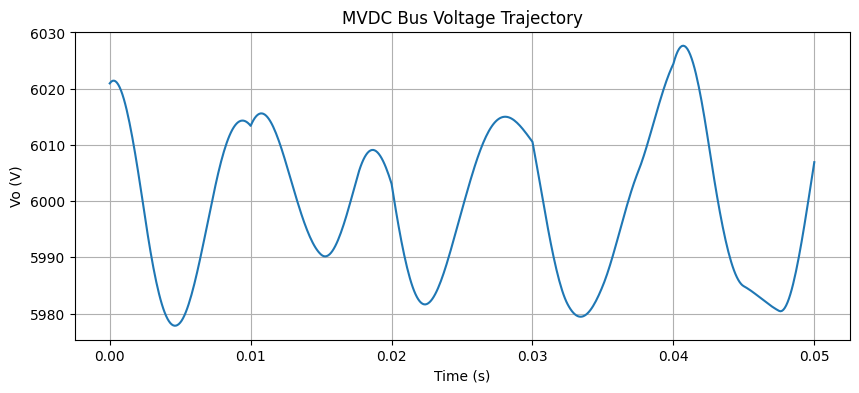

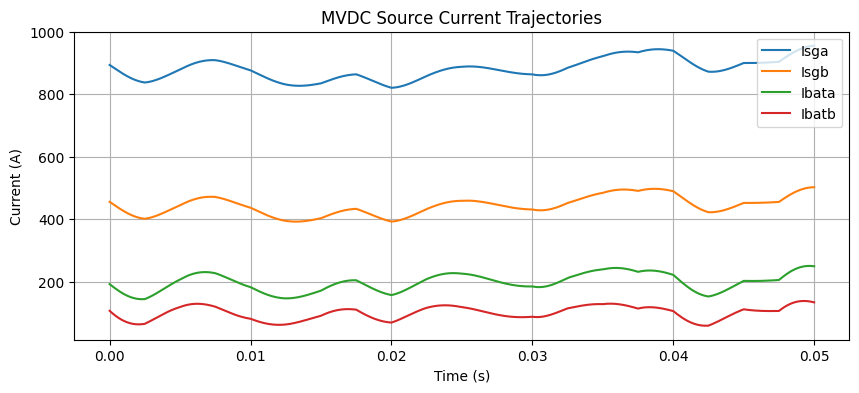

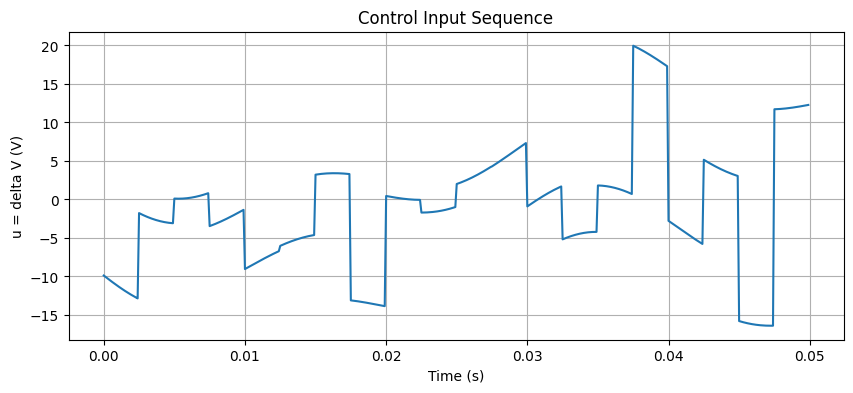

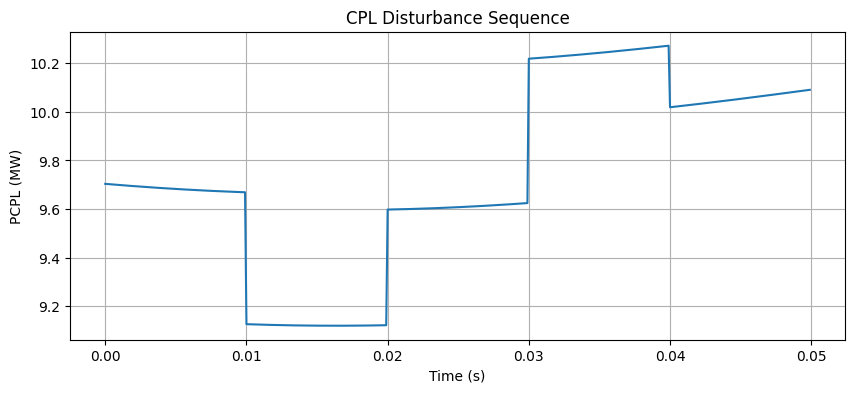

In [14]:
# ============================================================
# Plot one generated trajectory
# ============================================================

traj_id = 0

dt = 1e-4
num_steps = U_data.shape[1]
t_x = np.arange(num_steps + 1) * dt
t_u = np.arange(num_steps) * dt

X_np = X_data[traj_id].detach().cpu().numpy()
U_np = U_data[traj_id].detach().cpu().numpy()
D_np = D_data[traj_id].detach().cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(t_x, X_np[:, 0])
plt.xlabel("Time (s)")
plt.ylabel("Vo (V)")
plt.title("MVDC Bus Voltage Trajectory")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_x, X_np[:, 1], label="Isga")
plt.plot(t_x, X_np[:, 2], label="Isgb")
plt.plot(t_x, X_np[:, 3], label="Ibata")
plt.plot(t_x, X_np[:, 4], label="Ibatb")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title("MVDC Source Current Trajectories")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_u, U_np[:, 0])
plt.xlabel("Time (s)")
plt.ylabel("u = delta V (V)")
plt.title("Control Input Sequence")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_u, D_np[:, 0] / 1e6)
plt.xlabel("Time (s)")
plt.ylabel("PCPL (MW)")
plt.title("CPL Disturbance Sequence")
plt.grid(True)
plt.show()

In [15]:
# ============================================================
# Train / validation split
# ============================================================

num_traj = X_data.shape[0]
train_ratio = 0.8

num_train = int(train_ratio * num_traj)

perm = torch.randperm(num_traj, device=device)

train_idx = perm[:num_train]
val_idx = perm[num_train:]

X_train = X_data[train_idx]
U_train = U_data[train_idx]
D_train = D_data[train_idx]

X_val = X_data[val_idx]
U_val = U_data[val_idx]
D_val = D_data[val_idx]

print("X_train:", X_train.shape)
print("U_train:", U_train.shape)
print("D_train:", D_train.shape)

print("X_val:", X_val.shape)
print("U_val:", U_val.shape)
print("D_val:", D_val.shape)

X_train: torch.Size([160, 501, 5])
U_train: torch.Size([160, 500, 1])
D_train: torch.Size([160, 500, 1])
X_val: torch.Size([40, 501, 5])
U_val: torch.Size([40, 500, 1])
D_val: torch.Size([40, 500, 1])


In [16]:
#============================================================
# Normalize dataset
#============================================================

def compute_normalization_stats(
    X_train, U_train, D_train,
    x_op, u_op, d_op
):
    """
    Compute normalization statistics (mean and std) for states, inputs, and disturbances
    We will normalize around the operating point:
        x_norm = (x - x_op) / x_scale
        u_norm = (u - u_op) / u_scale
        d_norm = (d - d_op) / d_scale
    """

    # Deviation from operating point
    X_dev = X_train - x_op.reshape(1, 1, -1)
    U_dev = U_train - u_op.reshape(1, 1, -1)
    D_dev = D_train - d_op.reshape(1, 1, -1)

    # Data-driven scale based on training data
    x_scale = torch.std(X_dev.reshape(-1, X_dev.shape[-1]), dim=0) 
    u_scale = torch.std(U_dev.reshape(-1, U_dev.shape[-1]), dim=0)
    d_scale = torch.std(D_dev.reshape(-1, D_dev.shape[-1]), dim=0)

    # Avoid too-small scales
    x_min_scale = torch.tensor([10.0, 10.0, 10.0, 5.0, 5.0], device=X_train.device, dtype=X_train.dtype)
    u_min_scale = torch.tensor([510], device=U_train.device, dtype=U_train.dtype)
    d_min_scale = torch.tensor([1e5], device=D_train.device, dtype=D_train.dtype)


    x_scale = torch.maximum(x_scale, x_min_scale)
    u_scale = torch.maximum(u_scale, u_min_scale)
    d_scale = torch.maximum(d_scale, d_min_scale)

    return x_scale, u_scale, d_scale




In [17]:

x_scale, u_scale, d_scale = compute_normalization_stats(
    X_train=X_train,
    U_train=U_train,
    D_train=D_train,
    x_op=x_op,
    u_op=u_op,
    d_op=d_op
)

print("x_scale:", x_scale)
print("u_scale:", u_scale)
print("d_scale:", d_scale)

x_scale: tensor([16.1471, 40.4549, 34.5601, 32.0333, 23.6247], device='mps:0')
u_scale: tensor([510.], device='mps:0')
d_scale: tensor([487667.3438], device='mps:0')


In [18]:
# ============================================================
# Apply normalization
# ============================================================

def normalize_X(X, x_op, x_scale):
    return (X - x_op.reshape(1, 1, -1)) / x_scale.reshape(1, 1, -1)

def normalize_U(U, u_op, u_scale):
    return (U - u_op.reshape(1, 1, -1)) / u_scale.reshape(1, 1, -1)

def normalize_D(D, d_op, d_scale):
    return (D - d_op.reshape(1, 1, -1)) / d_scale.reshape(1, 1, -1)

def denormalize_X(Z, x_op, x_scale):
    return Z * x_scale.reshape(1, 1, -1) + x_op.reshape(1, 1, -1)


Xn_train = normalize_X(X_train, x_op, x_scale)
Un_train = normalize_U(U_train, u_op, u_scale)
Dn_train = normalize_D(D_train, d_op, d_scale)

Xn_val = normalize_X(X_val, x_op, x_scale)
Un_val = normalize_U(U_val, u_op, u_scale)
Dn_val = normalize_D(D_val, d_op, d_scale)

print("Xn_train:", Xn_train.shape)
print("Un_train:", Un_train.shape)
print("Dn_train:", Dn_train.shape)

print("Xn_val:", Xn_val.shape)
print("Un_val:", Un_val.shape)
print("Dn_val:", Dn_val.shape)

Xn_train: torch.Size([160, 501, 5])
Un_train: torch.Size([160, 500, 1])
Dn_train: torch.Size([160, 500, 1])
Xn_val: torch.Size([40, 501, 5])
Un_val: torch.Size([40, 500, 1])
Dn_val: torch.Size([40, 500, 1])


In [19]:
import torch.nn as nn
import torch.optim as optim
import copy

#============================================================
# MVDC Neural ODE function
#============================================================

class MVDCNODEFunc(nn.Module):
    def __init__(self, state_dim=5, input_dim=1, disturbance_dim=1, hidden_dim=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim + input_dim + disturbance_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, state_dim),
        )

    def forward(self, z, u_norm, d_norm):
        """
        z shape      : [batch_size, 5]
        u_norm shape : [batch_size, 1]
        d_norm shape : [batch_size, 1]

        return dzdt shape: [batch_size, 5]
        """

        inp = torch.cat([z, u_norm, d_norm], dim=1)
        dzdt = self.net(inp)

        return dzdt

In [20]:
# ============================================================
# Initialize model
# ============================================================

node_model = MVDCNODEFunc(
    state_dim=5,
    input_dim=1,
    disturbance_dim=1,
    hidden_dim=128
).to(device)

print(node_model)

MVDCNODEFunc(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)


In [21]:
# ============================================================
# RK4 step for normalized NODE
# ============================================================

def rk4_step_node_norm(node_func, z, u_norm, d_norm, dt):
    """
    One RK4 step in normalized state coordinates.

    z shape      : [batch_size, 5]
    u_norm shape : [batch_size, 1]
    d_norm shape : [batch_size, 1]
    """

    k1 = node_func(z, u_norm, d_norm)
    k2 = node_func(z + 0.5 * dt * k1, u_norm, d_norm)
    k3 = node_func(z + 0.5 * dt * k2, u_norm, d_norm)
    k4 = node_func(z + dt * k3, u_norm, d_norm)

    z_next = z + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return z_next

In [22]:
# ============================================================
# Rollout NODE over a time window
# ============================================================

def rollout_node_norm(node_func, z0, u_seq_norm, d_seq_norm, dt):
    """
    Rollout normalized NODE.

    z0 shape         : [batch_size, 5]
    u_seq_norm shape : [batch_size, horizon, 1]
    d_seq_norm shape : [batch_size, horizon, 1]

    return:
        z_pred shape : [batch_size, horizon + 1, 5]
    """

    batch_size = z0.shape[0]
    horizon = u_seq_norm.shape[1]

    z = z0
    z_list = [z]

    for k in range(horizon):
        u_k = u_seq_norm[:, k, :]
        d_k = d_seq_norm[:, k, :]

        z = rk4_step_node_norm(
            node_func=node_func,
            z=z,
            u_norm=u_k,
            d_norm=d_k,
            dt=dt
        )

        z_list.append(z)

    z_pred = torch.stack(z_list, dim=1)

    return z_pred

In [23]:
# ============================================================
# Sample random training windows
# ============================================================

def sample_random_windows(Xn, Un, Dn, batch_size, horizon):
    """
    Sample random trajectory windows.

    Xn shape: [num_traj, num_steps + 1, 5]
    Un shape: [num_traj, num_steps, 1]
    Dn shape: [num_traj, num_steps, 1]
    """

    device = Xn.device

    num_traj = Xn.shape[0]
    num_steps = Un.shape[1]

    traj_idx = torch.randint(
        low=0,
        high=num_traj,
        size=(batch_size,),
        device=device
    )

    start_idx = torch.randint(
        low=0,
        high=num_steps - horizon + 1,
        size=(batch_size,),
        device=device
    )

    x_time_offsets = torch.arange(horizon + 1, device=device)
    u_time_offsets = torch.arange(horizon, device=device)

    X_batch = Xn[
        traj_idx[:, None],
        start_idx[:, None] + x_time_offsets[None, :],
        :
    ]

    U_batch = Un[
        traj_idx[:, None],
        start_idx[:, None] + u_time_offsets[None, :],
        :
    ]

    D_batch = Dn[
        traj_idx[:, None],
        start_idx[:, None] + u_time_offsets[None, :],
        :
    ]

    return X_batch, U_batch, D_batch

In [24]:
# ============================================================
# Validation loss
# ============================================================

def evaluate_node_loss(
    node_model,
    Xn_eval,
    Un_eval,
    Dn_eval,
    dt,
    batch_size=64,
    horizon=50,
    num_batches=10
):
    node_model.eval()

    losses = []

    with torch.no_grad():
        for _ in range(num_batches):
            X_batch, U_batch, D_batch = sample_random_windows(
                Xn=Xn_eval,
                Un=Un_eval,
                Dn=Dn_eval,
                batch_size=batch_size,
                horizon=horizon
            )

            z0 = X_batch[:, 0, :]
            z_true = X_batch

            z_pred = rollout_node_norm(
                node_func=node_model,
                z0=z0,
                u_seq_norm=U_batch,
                d_seq_norm=D_batch,
                dt=dt
            )

            loss = torch.mean((z_pred - z_true) ** 2)
            losses.append(loss.item())

    node_model.train()

    return float(np.mean(losses))

In [25]:
#============================================================
# Train MVDC NODE
#============================================================

time_scale = 1e-3
dt_train = 1e-4
dt_model = dt_train / time_scale

num_epochs = 5000
batch_size = 64
horizon = 20

learning_rate = 1e-3
weight_decay = 1e-6

optimizer = optim.Adam(
    node_model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

best_val_loss = float("inf")
best_state_dict = None

train_loss_history = []
val_loss_history = []

print("=" * 80)
print("Training MVDC NODE")
print("=" * 80)

for epoch in range(1, num_epochs + 1):

    node_model.train()

    X_batch, U_batch, D_batch = sample_random_windows(
        Xn=Xn_train,
        Un=Un_train,
        Dn=Dn_train,
        batch_size=batch_size,
        horizon=horizon
    )

    z0 = X_batch[:, 0, :]
    z_true = X_batch

    z_pred = rollout_node_norm(
        node_func=node_model,
        z0=z0,
        u_seq_norm=U_batch,
        d_seq_norm=D_batch,
        dt=dt_model
    )

    loss = torch.mean((z_pred - z_true) ** 2)

    optimizer.zero_grad()
    loss.backward()

    torch.nn.utils.clip_grad_norm_(node_model.parameters(), max_norm=1.0)

    optimizer.step()

    train_loss_history.append(loss.item())

    if epoch % 10 == 0 or epoch == 1:
        val_loss = evaluate_node_loss(
            node_model=node_model,
            Xn_eval=Xn_val,
            Un_eval=Un_val,
            Dn_eval=Dn_val,
            dt=dt_model,
            batch_size=batch_size,
            horizon=horizon,
            num_batches=5
        )

        val_loss_history.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(node_model.state_dict())

        print(
            f"Epoch {epoch:04d} | "
            f"Train Loss: {loss.item():.6e} | "
            f"Val Loss: {val_loss:.6e} | "
            f"Best Val: {best_val_loss:.6e}"
        )

print("=" * 80)
print("Training finished.")
print("Best validation loss:", best_val_loss)
print("=" * 80)

# Load best model
if best_state_dict is not None:
    node_model.load_state_dict(best_state_dict)

Training MVDC NODE
Epoch 0001 | Train Loss: 2.839338e-01 | Val Loss: 2.622029e-01 | Best Val: 2.622029e-01
Epoch 0010 | Train Loss: 8.625978e-02 | Val Loss: 7.700910e-02 | Best Val: 7.700910e-02
Epoch 0020 | Train Loss: 7.015249e-02 | Val Loss: 6.508267e-02 | Best Val: 6.508267e-02
Epoch 0030 | Train Loss: 6.198522e-02 | Val Loss: 5.416257e-02 | Best Val: 5.416257e-02
Epoch 0040 | Train Loss: 4.519736e-02 | Val Loss: 5.929345e-02 | Best Val: 5.416257e-02
Epoch 0050 | Train Loss: 5.970252e-02 | Val Loss: 5.295974e-02 | Best Val: 5.295974e-02
Epoch 0060 | Train Loss: 5.818205e-02 | Val Loss: 5.314246e-02 | Best Val: 5.295974e-02
Epoch 0070 | Train Loss: 5.731269e-02 | Val Loss: 5.157569e-02 | Best Val: 5.157569e-02
Epoch 0080 | Train Loss: 4.608840e-02 | Val Loss: 5.384151e-02 | Best Val: 5.157569e-02
Epoch 0090 | Train Loss: 6.133021e-02 | Val Loss: 5.102826e-02 | Best Val: 5.102826e-02
Epoch 0100 | Train Loss: 4.592316e-02 | Val Loss: 5.558382e-02 | Best Val: 5.102826e-02
Epoch 0110 | 

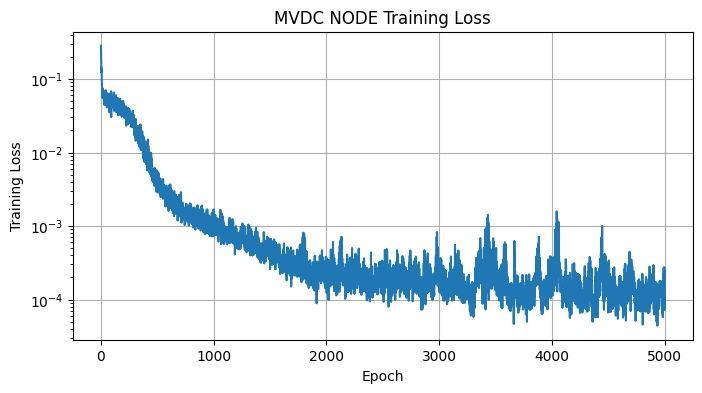

In [26]:
# ============================================================
# Plot training loss
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MVDC NODE Training Loss")
plt.grid(True)
plt.show()

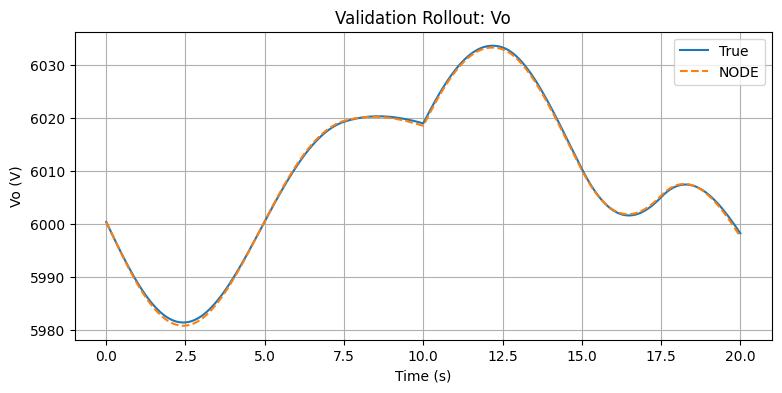

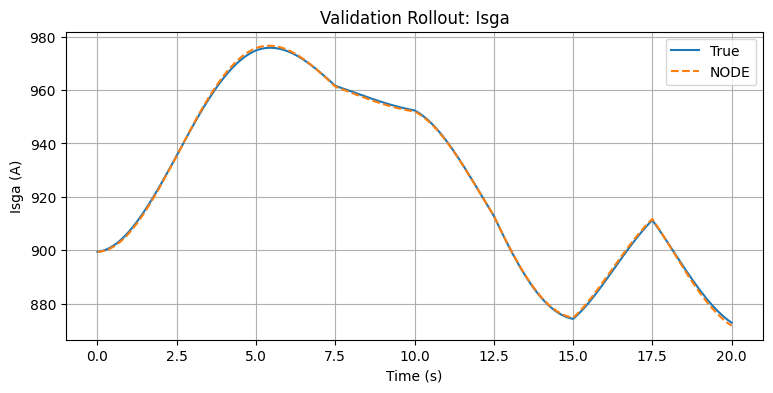

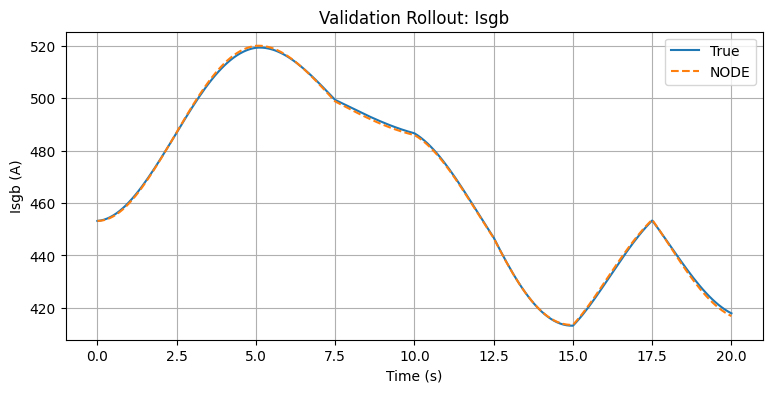

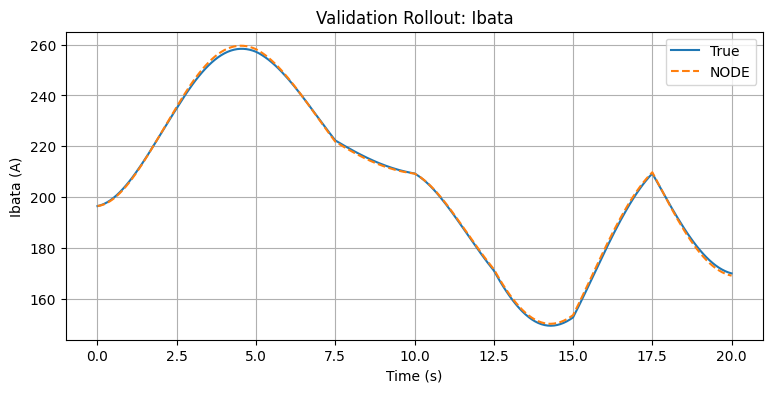

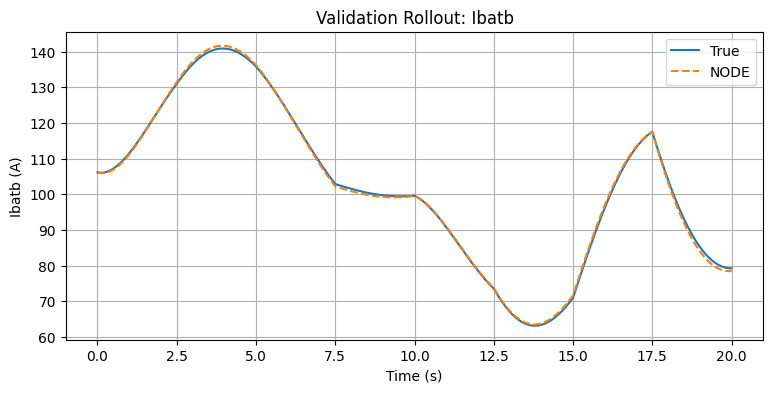

In [27]:
# ============================================================
# Validate one rollout visually
# ============================================================

node_model.eval()

test_horizon = 200
traj_id = 0
start_idx = 0

X_test = Xn_val[traj_id:traj_id+1, start_idx:start_idx+test_horizon+1, :]
U_test = Un_val[traj_id:traj_id+1, start_idx:start_idx+test_horizon, :]
D_test = Dn_val[traj_id:traj_id+1, start_idx:start_idx+test_horizon, :]

with torch.no_grad():
    Z_pred = rollout_node_norm(
        node_func=node_model,
        z0=X_test[:, 0, :],
        u_seq_norm=U_test,
        d_seq_norm=D_test,
        dt=dt_model
    )

# Denormalize for plotting
X_true_abs = denormalize_X(X_test, x_op, x_scale)
X_pred_abs = denormalize_X(Z_pred, x_op, x_scale)

X_true_np = X_true_abs.squeeze(0).detach().cpu().numpy()
X_pred_np = X_pred_abs.squeeze(0).detach().cpu().numpy()

t = np.arange(test_horizon + 1) * dt_model

state_names = ["Vo", "Isga", "Isgb", "Ibata", "Ibatb"]
state_units = ["V", "A", "A", "A", "A"]

for j in range(5):
    plt.figure(figsize=(9, 4))
    plt.plot(t, X_true_np[:, j], label="True")
    plt.plot(t, X_pred_np[:, j], "--", label="NODE")
    plt.xlabel("Time (s)")
    plt.ylabel(f"{state_names[j]} ({state_units[j]})")
    plt.title(f"Validation Rollout: {state_names[j]}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [28]:
# ============================================================
# Save NODE checkpoint
# ============================================================

checkpoint = {
    "model_state_dict": node_model.state_dict(),
    "x_op": x_op.detach().cpu(),
    "u_op": u_op.detach().cpu(),
    "d_op": d_op.detach().cpu(),
    "x_scale": x_scale.detach().cpu(),
    "u_scale": u_scale.detach().cpu(),
    "d_scale": d_scale.detach().cpu(),
    "params": params,
    "dt": dt_train,
    "best_val_loss": best_val_loss,
}

torch.save(checkpoint, "mvdc_node_checkpoint.pt")

print("Saved checkpoint: mvdc_node_checkpoint.pt")

Saved checkpoint: mvdc_node_checkpoint.pt


In [29]:
# ============================================================
# Regression metrics
# ============================================================

def compute_prediction_metrics(y_true, y_pred, state_names=None, eps=1e-8):
    """
    y_true shape: [num_samples, time, state_dim]
    y_pred shape: [num_samples, time, state_dim]

    Metrics are computed per state.
    """

    if state_names is None:
        state_names = [f"x{i}" for i in range(y_true.shape[-1])]

    err = y_pred - y_true

    mae = torch.mean(torch.abs(err), dim=(0, 1))
    rmse = torch.sqrt(torch.mean(err ** 2, dim=(0, 1)))

    true_min = torch.min(y_true, dim=0).values
    true_min = torch.min(true_min, dim=0).values

    true_max = torch.max(y_true, dim=0).values
    true_max = torch.max(true_max, dim=0).values

    data_range = true_max - true_min
    nrmse = rmse / (data_range + eps)

    ss_res = torch.sum(err ** 2, dim=(0, 1))
    true_mean = torch.mean(y_true, dim=(0, 1), keepdim=True)
    ss_tot = torch.sum((y_true - true_mean) ** 2, dim=(0, 1))

    r2 = 1.0 - ss_res / (ss_tot + eps)

    metrics = {}

    for i, name in enumerate(state_names):
        metrics[name] = {
            "MAE": mae[i].item(),
            "RMSE": rmse[i].item(),
            "NRMSE": nrmse[i].item(),
            "R2": r2[i].item(),
        }

    return metrics

In [37]:
# ============================================================
# Evaluate NODE prediction for one horizon
# ============================================================

def evaluate_node_prediction_horizon(
    node_model,
    Xn_eval,
    Un_eval,
    Dn_eval,
    x_op,
    x_scale,
    dt_model,
    horizon,
    batch_size=128,
    num_batches=20,
    state_names=None
):
    """
    Evaluate NODE prediction over a given horizon.

    Returns metrics in absolute physical units.
    """

    if state_names is None:
        state_names = ["Vo", "Isga", "Isgb", "Ibata", "Ibatb"]

    node_model.eval()

    true_list = []
    pred_list = []

    with torch.no_grad():
        for _ in range(num_batches):

            X_batch, U_batch, D_batch = sample_random_windows(
                Xn=Xn_eval,
                Un=Un_eval,
                Dn=Dn_eval,
                batch_size=batch_size,
                horizon=horizon
            )

            z0 = X_batch[:, 0, :]

            Z_pred = rollout_node_norm(
                node_func=node_model,
                z0=z0,
                u_seq_norm=U_batch,
                d_seq_norm=D_batch,
                dt=dt_model
            )

            X_true_abs = denormalize_X(X_batch, x_op, x_scale)
            X_pred_abs = denormalize_X(Z_pred, x_op, x_scale)

            # Exclude t=0 because prediction starts exactly from true initial state
            true_list.append(X_true_abs[:, 1:, :].detach().cpu())
            pred_list.append(X_pred_abs[:, 1:, :].detach().cpu())

    y_true = torch.cat(true_list, dim=0)
    y_pred = torch.cat(pred_list, dim=0)

    metrics = compute_prediction_metrics(
        y_true=y_true,
        y_pred=y_pred,
        state_names=state_names
    )

    node_model.train()

    return metrics

In [38]:
# ============================================================
# Evaluate multiple prediction horizons
# ============================================================

import pandas as pd

state_names = ["Vo", "Isga", "Isgb", "Ibata", "Ibatb"]

dt_phys = 1e-4
time_scale = 1e-3
dt_model = dt_phys / time_scale

horizons = [5, 10, 20, 50, 100]

rows = []

for H in horizons:
    if H > Un_val.shape[1]:
        continue

    metrics_H = evaluate_node_prediction_horizon(
        node_model=node_model,
        Xn_eval=Xn_val,
        Un_eval=Un_val,
        Dn_eval=Dn_val,
        x_op=x_op,
        x_scale=x_scale,
        dt_model=dt_model,
        horizon=H,
        batch_size=128,
        num_batches=20,
        state_names=state_names
    )

    for state in state_names:
        rows.append({
            "Horizon_steps": H,
            "Horizon_time_ms": H * dt_phys * 1000.0,
            "State": state,
            "MAE": metrics_H[state]["MAE"],
            "RMSE": metrics_H[state]["RMSE"],
            "NRMSE": metrics_H[state]["NRMSE"],
            "R2": metrics_H[state]["R2"],
        })

df_metrics = pd.DataFrame(rows)

df_metrics

,Horizon_steps,Horizon_time_ms,State,MAE,RMSE,NRMSE,R2
0,5,0.5,Vo,0.025406,0.038327,0.000368,0.999994
1,5,0.5,Isga,0.076435,0.113357,0.000496,0.999991
2,5,0.5,Isgb,0.071002,0.108336,0.000562,0.999989
3,5,0.5,Ibata,0.078561,0.121625,0.000609,0.999985
4,5,0.5,Ibatb,0.073889,0.112794,0.000721,0.999977
5,10,1.0,Vo,0.049686,0.074795,0.000702,0.999977
6,10,1.0,Isga,0.128308,0.186364,0.000820,0.999977
7,10,1.0,Isgb,0.118984,0.176926,0.000918,0.999972
8,10,1.0,Ibata,0.127638,0.191966,0.000962,0.999963
9,10,1.0,Ibatb,0.116193,0.172936,0.001098,0.999946


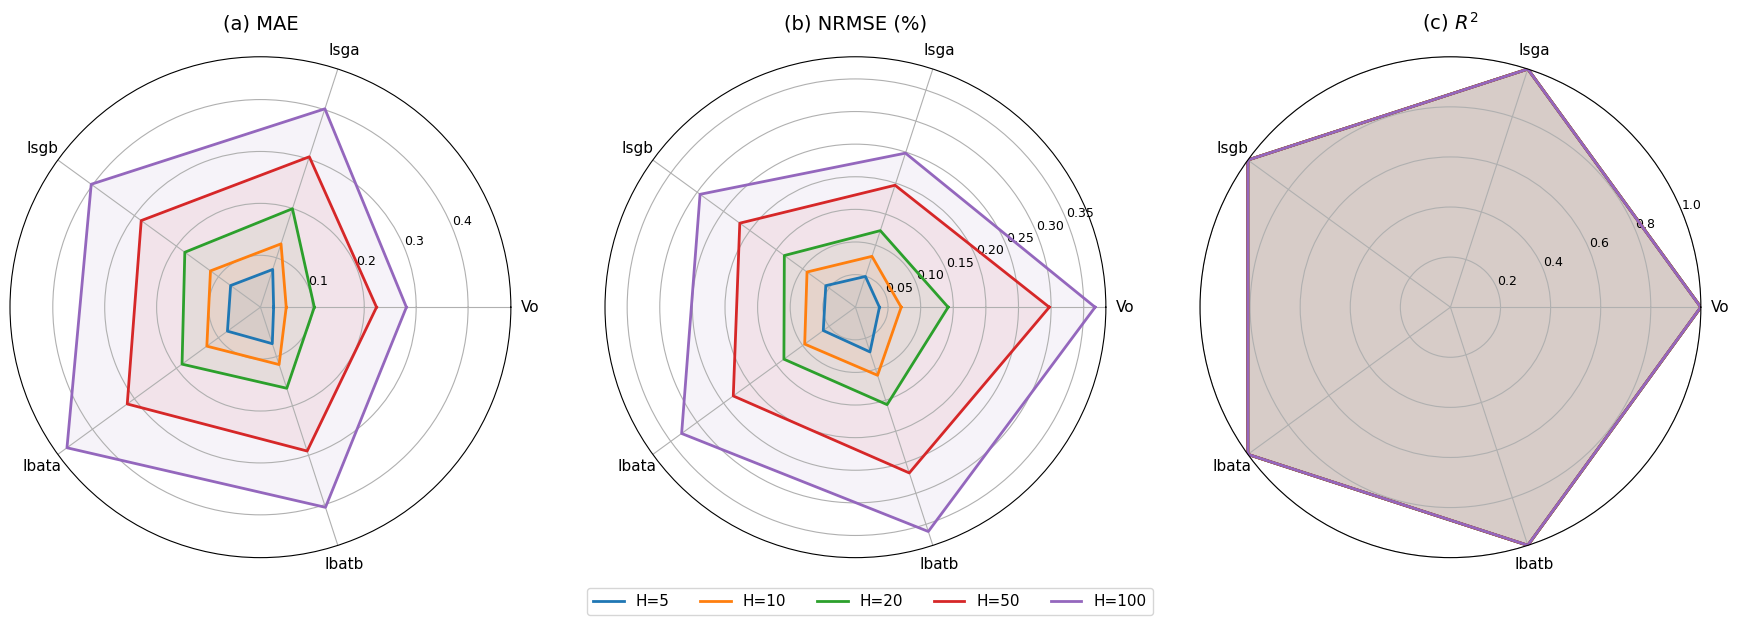

In [ ]:
# ============================================================
# Radar chart for NODE prediction metrics across horizons
# Requires df_metrics with columns:
# ["Horizon_steps", "Horizon_time_ms", "State", "MAE", "RMSE", "NRMSE", "R2"]
# ============================================================

# Choose states and horizons to display
state_order = ["Vo", "Isga", "Isgb", "Ibata", "Ibatb"]
horizon_order = sorted(df_metrics["Horizon_steps"].unique())

# Optional: rename states for plot labels
state_label_map = {
    "Vo": "Vo",
    "Isga": "Isga",
    "Isgb": "Isgb",
    "Ibata": "Ibata",
    "Ibatb": "Ibatb",
}

state_labels = [state_label_map[s] for s in state_order]

# Radar angles
num_states = len(state_order)
angles = np.linspace(0, 2 * np.pi, num_states, endpoint=False).tolist()
angles += angles[:1]  # close polygon


def get_metric_values(df, metric_name, horizon, state_order, multiply=1.0):
    """
    Return metric values ordered by state_order and closed for radar plot.
    """
    sub = df[df["Horizon_steps"] == horizon].copy()

    values = []
    for state in state_order:
        row = sub[sub["State"] == state]

        if row.empty:
            values.append(np.nan)
        else:
            values.append(row[metric_name].values[0] * multiply)

    values += values[:1]  # close polygon
    return values


def plot_radar_metric(ax, df, metric_name, title, state_order, horizon_order, multiply=1.0):
    """
    Plot one radar chart for a metric.
    """

    for H in horizon_order:
        values = get_metric_values(
            df=df,
            metric_name=metric_name,
            horizon=H,
            state_order=state_order,
            multiply=multiply
        )

        ax.plot(
            angles,
            values,
            linewidth=2,
            label=f"H={H}"
        )

        ax.fill(
            angles,
            values,
            alpha=0.08
        )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(state_labels, fontsize=11)

    ax.set_title(title, fontsize=14, pad=20)

    ax.grid(True)

    # Make labels easier to read
    ax.tick_params(axis="y", labelsize=9)


# ============================================================
# Create radar charts
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    subplot_kw={"polar": True}
)

plot_radar_metric(
    ax=axes[0],
    df=df_metrics,
    metric_name="MAE",
    title="(a) MAE",
    state_order=state_order,
    horizon_order=horizon_order,
    multiply=1.0
)

plot_radar_metric(
    ax=axes[1],
    df=df_metrics,
    metric_name="NRMSE",
    title="(b) NRMSE (%)",
    state_order=state_order,
    horizon_order=horizon_order,
    multiply=100.0
)

plot_radar_metric(
    ax=axes[2],
    df=df_metrics,
    metric_name="R2",
    title=r"(c) $R^2$",
    state_order=state_order,
    horizon_order=horizon_order,
    multiply=1.0
)

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(horizon_order),
    fontsize=11
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [33]:
# ============================================================
#  Plot one validation rollout
# ============================================================

def plot_node_validation_rollout(
    node_model,
    Xn_val,
    Un_val,
    Dn_val,
    x_op,
    x_scale,
    dt_model,
    dt_phys,
    traj_id=0,
    start_idx=0,
    horizon=100
):
    node_model.eval()

    X_test = Xn_val[
        traj_id:traj_id+1,
        start_idx:start_idx+horizon+1,
        :
    ]

    U_test = Un_val[
        traj_id:traj_id+1,
        start_idx:start_idx+horizon,
        :
    ]

    D_test = Dn_val[
        traj_id:traj_id+1,
        start_idx:start_idx+horizon,
        :
    ]

    with torch.no_grad():
        Z_pred = rollout_node_norm(
            node_func=node_model,
            z0=X_test[:, 0, :],
            u_seq_norm=U_test,
            d_seq_norm=D_test,
            dt=dt_model
        )

    X_true_abs = denormalize_X(X_test, x_op, x_scale)
    X_pred_abs = denormalize_X(Z_pred, x_op, x_scale)

    X_true_np = X_true_abs.squeeze(0).detach().cpu().numpy()
    X_pred_np = X_pred_abs.squeeze(0).detach().cpu().numpy()

    t = np.arange(horizon + 1) * dt_phys

    state_names = ["Vo", "Isga", "Isgb", "Ibata", "Ibatb"]
    state_units = ["V", "A", "A", "A", "A"]

    for j in range(5):
        plt.figure(figsize=(9, 4))
        plt.plot(t, X_true_np[:, j], label="True")
        plt.plot(t, X_pred_np[:, j], "--", label="NODE")
        plt.xlabel("Time (s)")
        plt.ylabel(f"{state_names[j]} ({state_units[j]})")
        plt.title(f"Validation Rollout | {state_names[j]} | H={horizon}")
        plt.legend()
        plt.grid(True)
        plt.show()

    node_model.train()

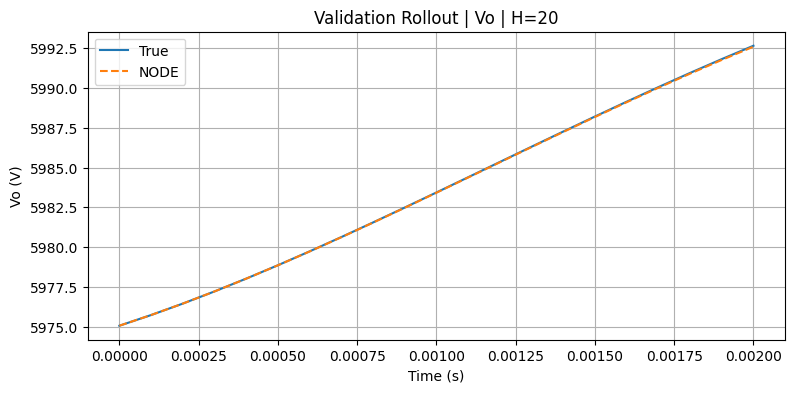

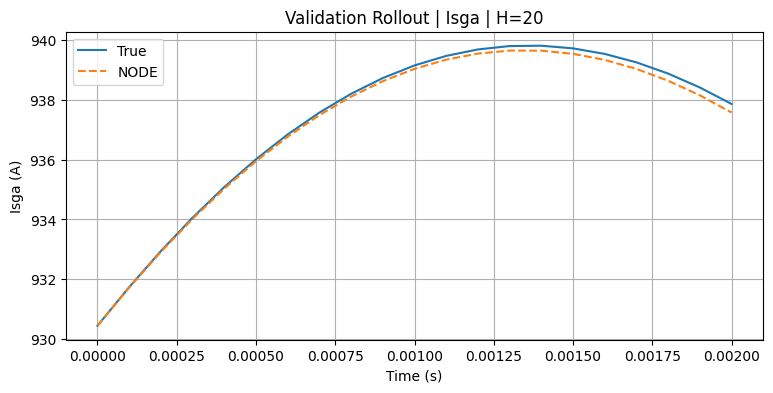

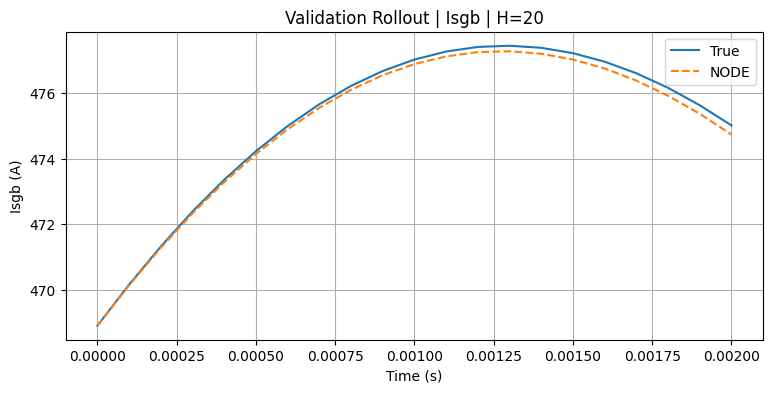

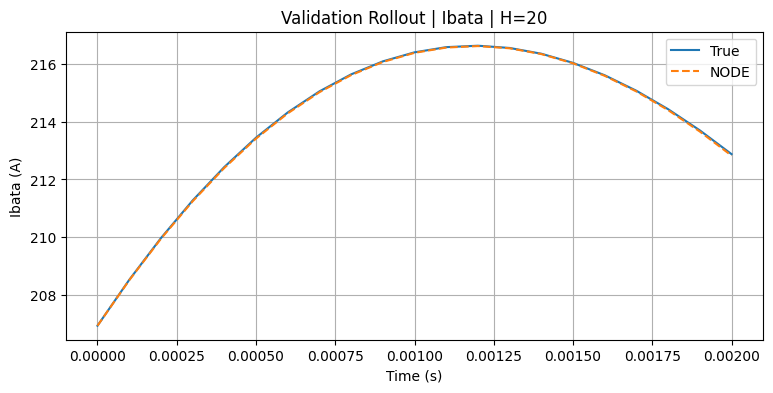

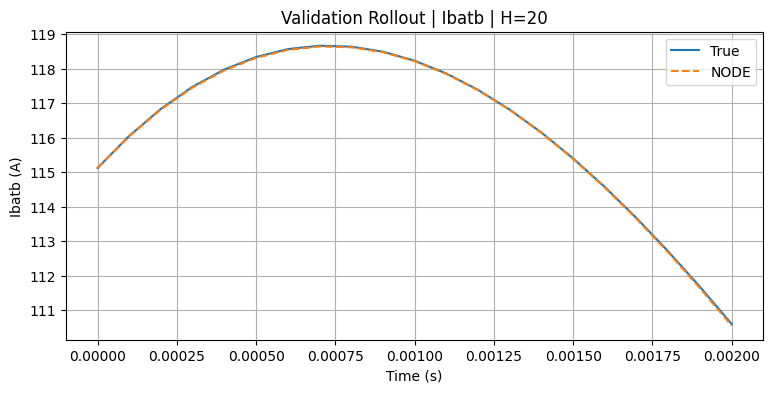

In [40]:
plot_node_validation_rollout(
    node_model=node_model,
    Xn_val=Xn_val,
    Un_val=Un_val,
    Dn_val=Dn_val,
    x_op=x_op,
    x_scale=x_scale,
    dt_model=dt_model,
    dt_phys=dt,
    traj_id=5,
    start_idx=5,
    horizon=20
)